<a href="https://colab.research.google.com/github/pritishma-shakya/ai-and-machine-learning/blob/main/PritishmaShakya_2408412_Tutorial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.2.1 Data Pre – processing.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Step1: Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Sem6AI/Iris.csv")

# Step2: Dataset Information
print("Dataset Preview: ")
print(df.head())
print("\nDataset Information: ")
print(df.info())

# Step3: Extract features (X) and target labels (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step4: Convert categorical labels to numeric
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step5: One-Hot Encode the Labels
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1,1))

# Display results
print("\nUnique Classes: ", np.unique(y))
print("\nEncoded Labels: ", y_encoded)
print("\nOne-Hot Encoded Labels: \n", y_one_hot[:5])

# Step6: Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot)
# Output shapes
print("\nShapes:")
print("X_train: ", X_train.shape, "y_train: ", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

Dataset Preview: 
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
m

2.3.1. Softmax Regression as Learning Function.

In [23]:
import numpy as np
def softmax(z):
  """
  Compute the softmax probabilities for a given input matrix.
  Parameters:
  z (numpy.ndarray): Logits(raw scores) of shape (m, n), where
                    - m is the number of samples
                    - n is the number of classes
  Returns:
  numpy.ndarray: Softmax probabilities of shape (m, n), where
                each row sumns to 1 and represents the probability
                distribution over classes.
  Notes:
  - The input to softmax is typically computed as : z = XW+b
  - Uses numerical stabilization by subtracting the max value per row.
  """
  # Prevent numerical instability by normalizing input
  z_shifted = z-np.max(z, axis=1, keepdims=True)
  exp_z = np.exp(z_shifted)
  return exp_z / np.sum(exp_z, axis=1, keepdims=True)

2.4.1. Implementating Categorical Cross Entropy Loss Function


In [24]:
def loss_softmax(y_pred, y):
  """
  Compute the cross-entropy loss.
  Parameters:
  y_pred (numpy.ndarray): Predicted probabilities of shape (n, c), where
                          - n is the number of samples
                          - c is the number of classes
  y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
  Returns:
  float: Cross-entropy loss.
  """
  # To avoid log(0)
  epsilon = 1e-12
  # Prevent log(0) by clipping values
  y_pred = np.clip(y_pred, epsilon, 1.0-epsilon)
  # Number of samples
  n = y.shape[0]
  loss = -np.sum(y*np.log(y_pred))/n
  return loss

2.4.2. Implementing Cost Function

In [25]:
def cost_softmax(X, y, W, b):
  """
  Compute the softmax regression cost (cross-entropy loss).
  Parameter:
  X(numpy.ndarray): Feature matrix of shape (n, d), where
                  - n is the number of samples
                  - d is the number of features
  y(numpy.ndarray): True labels (one-hot encoded) of shape (n, c), where
                  - c is the number of classes
  W(numpy.ndarray): Weight matrix of shape (d, c)
  b(numpy.ndarray): Bias vector of shape (c,)
  Returns:
  float: Softmax cost(cost-entropy loss).
  """
  # Number of samples
  n = X.shape[0]
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  cost = loss_softmax(y_pred, y)
  return cost

2.6.1.1. Computing the gradients

In [26]:
def compute_gradient_softmax(X, y, W, b):
  """
  Compute the gradients of the cost function with respect to weights and biases.
  Parameters:
  X (numpy.ndarray): Feature matrix of shape(n, d)
  y (numpy.ndarray): True labels (one-hot encoded) of shape(n, c)
  W (numpy.ndarray): Weight matrix of shape(d, c)
  b (numpy.ndarray): Bias vector of shape(c,)
  Returns:
  tuple: Gradients with respect to weights(d, c) and biases (c,).
  """
  n, d = X.shape
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  # Gradient with respect to weights
  grad_W = np.dot(X.T, (y_pred-y))/n
  # Gradient with respect to biases
  grad_b = np.sum(y_pred - y, axis = 0)/n
  return grad_W, grad_b

2.6.2. Implementing Gradient Descent

In [27]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost = False):
  """
  Perform gradient descent to optimize the weights and biases.
  Parameters:
  X (numpy.ndarray): Feature matrix of shape(n, d)
  y (numpy.ndarray): True labels (one-hot encoded) of shape(n, c)
  W (numpy.ndarray): Weight matrix of shape(d, c)
  b (numpy.ndarray): Bias vector of shape(c,)
  alpha (float): Learning rate
  n_iter (int): Number of iterations
  show_cost (bool): Whether to display the cost at intervals
  Returns:
  tuple: Optimized weights(d, c) and biases(c,), and cost history.
  """
  cost_history = []
  for i in range(n_iter):
    # Compute gradients
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

    # Update weights and biases using the gradients
    W -= alpha * grad_W
    b -= alpha * grad_b

    # Compute and store cost
    cost = cost_softmax(X, y, W, b)
    cost_history.append(cost)

    # Print cost at regular intervals
    if show_cost and (i % 100 == 0 or i == n_iter-1):
      print(f"Iteration {i}: Cost= {cost:.6f}")
  return W, b, cost_history

2.7. Implementing a Decision Function

In [28]:
def predict_softmax(X, W, b):
  """
  Predict the class labels for a set of samples using the trained softmax model.
  Parameters:
  X (numpy.ndarray): Feature matrix of shape(n, d), where
                    - n is the number of samples
                    - d is the number of features
  W (numpy.ndarray): Weight matrix of shape(d, c), where c is the number of classes
  b (numpy.ndarray): Bias vector of shape(c,)
  Returns:
  numpy.ndarray: Predicted class labels of shape(n,), where each value is the index of predicted class
  """
  # Compute the scores (logits)
  z = np.dot(X, W)+b
  # Get the probabilities using the softmax function
  y_pred = softmax(z)

  # Assign the class with the highest probability
  predicted_classes = np.argmax(y_pred, axis = 1)
  return predicted_classes

2.8. Training the Model

Iteration 0: Cost= 18.233005
Iteration 100: Cost= 16.121756
Iteration 200: Cost= 15.155852
Iteration 300: Cost= 5.996992
Iteration 400: Cost= 14.038488
Iteration 500: Cost= 10.654347
Iteration 600: Cost= 4.050420
Iteration 700: Cost= 14.052475
Iteration 800: Cost= 9.862880
Iteration 900: Cost= 9.011592
Iteration 999: Cost= 5.113793


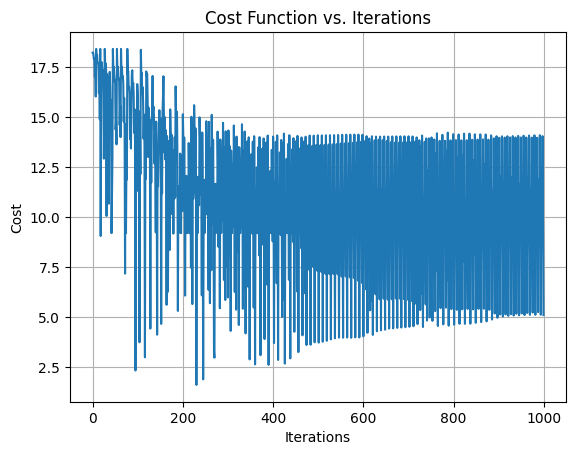

In [29]:
import matplotlib.pyplot as plt
# Initialize the wights and biases
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes
W = np.random.randn(d, c)*0.01  # Small random weights
b = np.zeros(c) # Bias initialized to 0
# Set hyperparameters
alpha = 0.1 # Learning rate
n_iter = 1000 # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost = True)

# Plot the cost hostory to visualize the convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

In [30]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
# Evaluation Function
def evaluate_classification(y_true, y_pred):
  """
  Evaluate classification performance using confusion matrix, precision, recall, F1 score, and accuracy.
  Parameters:
  y_true (numpy.ndarray): True labels
  y_pred (numpy.ndarray): Predicted labels
  Returns:
  tuple: Confusion matrix, precision, recall, F1 score, and accuracy.
  """
  # Compute Confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # Compute precision, recall, f1-score and accuracy
  precision = precision_score(y_true, y_pred, average = 'weighted')
  recall = recall_score(y_true, y_pred, average = 'weighted')
  f1 = f1_score(y_true, y_pred, average = 'weighted')
  accuracy = accuracy_score(y_true, y_pred)
  return cm, precision, recall, f1, accuracy

In [31]:
y_pred_test = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis = 1)

cm, precision, recall, f1, accuracy = evaluate_classification(y_test_labels, y_pred_test)

print("Confusion Matrix: \n", cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix: 
 [[10  0  0]
 [ 2  5  3]
 [ 0  0 10]]
Precision: 0.87
Recall: 0.83
F1 Score: 0.82
Accuracy: 0.83
